In [1]:
library(Rssa)
library(TTR)
library(quantmod)
library(xts)
library(tseries)
#library(TSA)
library(ggplot2)
library(PerformanceAnalytics) 
library(Metrics)
library(tseries)
library(dygraphs) 
library(Metrics)

Warning message:
"package 'Rssa' was built under R version 4.4.3"
Cargando paquete requerido: svd

Warning message:
"package 'svd' was built under R version 4.4.3"
Cargando paquete requerido: forecast

Warning message:
"package 'forecast' was built under R version 4.4.3"

Adjuntando el paquete: 'Rssa'


The following object is masked from 'package:stats':

    decompose


Warning message:
"package 'TTR' was built under R version 4.4.3"
Warning message:
"package 'quantmod' was built under R version 4.4.3"
Cargando paquete requerido: xts

Warning message:
"package 'xts' was built under R version 4.4.3"
Cargando paquete requerido: zoo

Warning message:
"package 'zoo' was built under R version 4.4.3"

Adjuntando el paquete: 'zoo'


The following objects are masked from 'package:base':

    as.Date, as.Date.numeric


Registered S3 method overwritten by 'quantmod':
  method            from
  as.zoo.data.frame zoo 

Warning message:
"package 'tseries' was built under R version 4.4.3"
Warning 

In [2]:
# Descargar datos
options(digits=3)
options(warn=-1)

#Obtención DATOS:
META<-getSymbols("META", from="2016-05-01", to="2018-01-28",auto.assign = FALSE)
META<-na.omit(META)
META<-META[,4]
head(META)
colnames(META)<-c("META")

           META.Close
2016-05-02        119
2016-05-03        117
2016-05-04        118
2016-05-05        118
2016-05-06        119
2016-05-09        119

In [3]:
# Graficar 
Precios<- dygraph(META[,c(1)], main="Precios META") %>%
  dyAxis("y", label = "Precios") %>%
  dyRangeSelector(dateWindow = c("2016-05-01", "2018-01-28"))%>%
  dyOptions(colors = RColorBrewer::brewer.pal(4,"Set1"))
Precios

HTML widgets cannot be represented in plain text (need html)

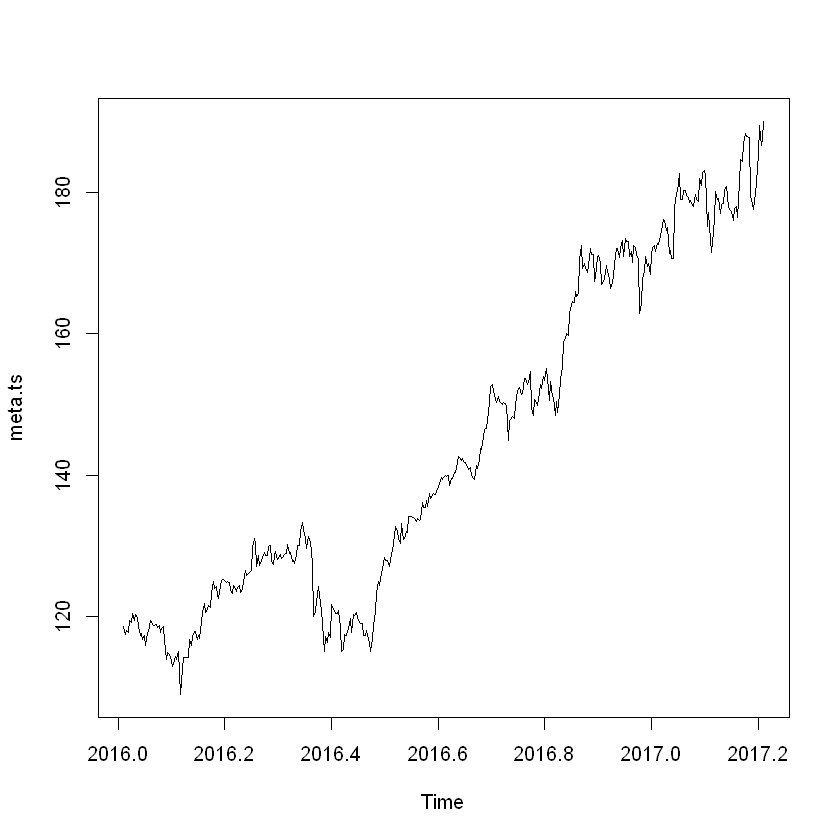

In [4]:
# pasar los datos de formato xts a ts, que es el formato que emplea SSA. 
META <- data.frame(date=index(META), coredata(META))
META1<-META$META
##pasamos a ts
meta.ts<-ts(META1, start=c(2016,05), frequency = 365)
plot(meta.ts)

In [5]:
# Partición de datos en entrenamiento 95% y prueba 5%
h <- round(length(meta.ts)*0.05, digits = 0 )

train<-meta.ts[1:(length(meta.ts)-h)]
test<-meta.ts[(length(meta.ts)-h+1):length(meta.ts)]
tail(train)
head(test)
str(test)

train.ts=ts(train,start=c(2016,05), frequency = 365)

[1] 180 181 180 178 177 177

[1] 176 178 178 176 181 185

 num [1:22] 176 178 178 176 181 ...


In [6]:
##SSA embeding y separación:
s1<-ssa(train.ts)  
s1


Call:
ssa(x = train.ts)

Series length: 417,	Window length: 209,	SVD method: eigen
Special triples:  0

Computed:
Eigenvalues: 50,	Eigenvectors: 50,	Factor vectors: 0

Precached: 0 elementary series (0 MiB)

Overall memory consumption (estimate): 0.0864 MiB

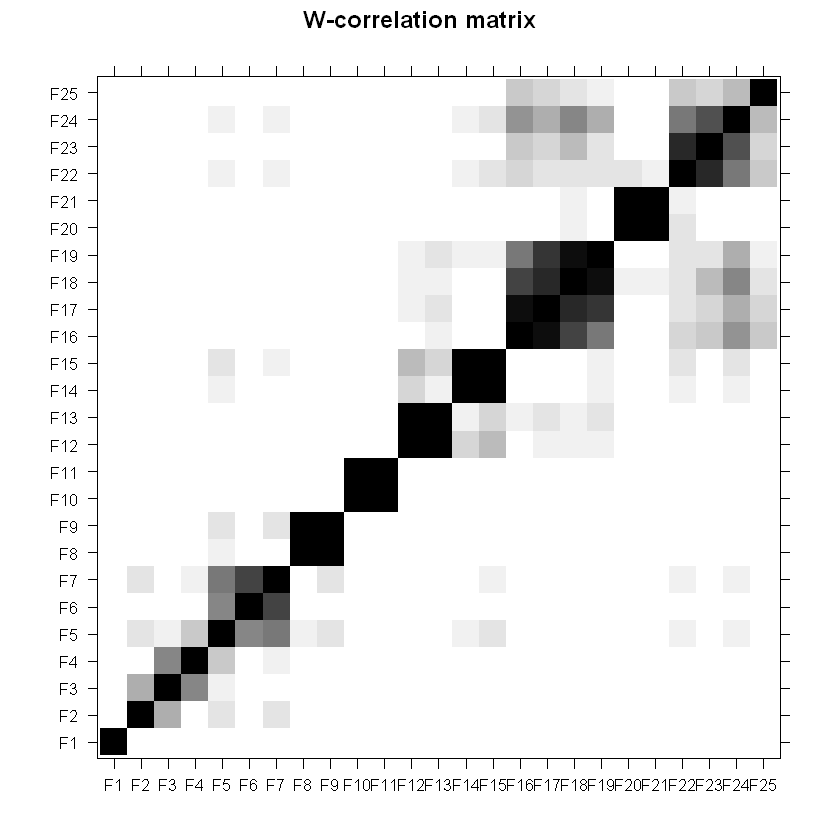

In [7]:
##Reconstrucción: emplear las herramientas visuales para la selección.
wplot<-wcor(s1, group=1:25)
plot(wplot)

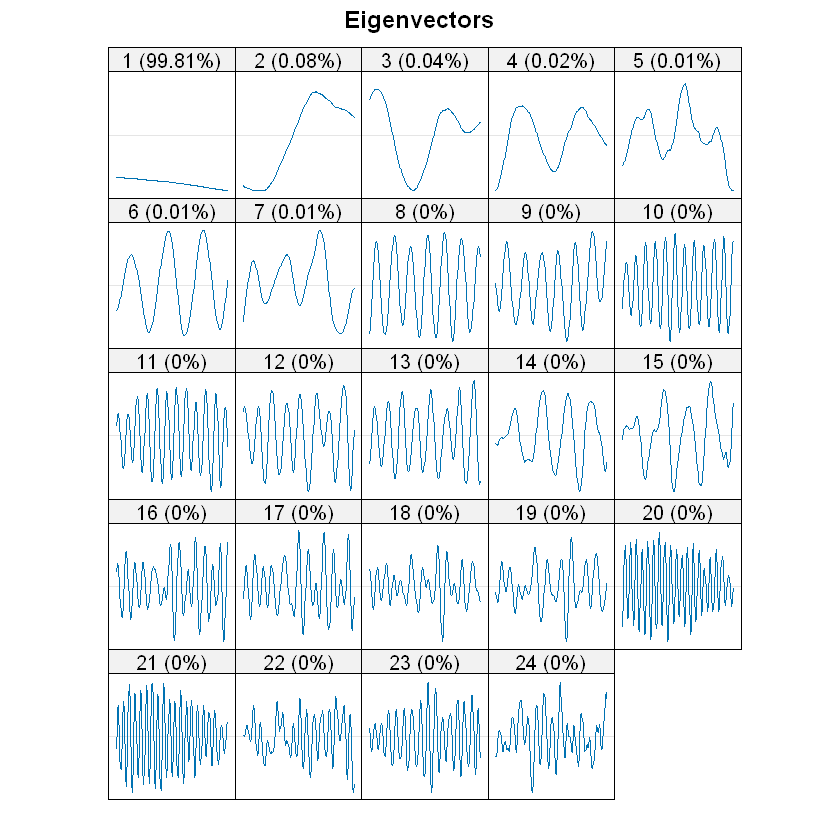

In [8]:
#Grafica por componente
plot(s1, type="vectors", idx=1:24)

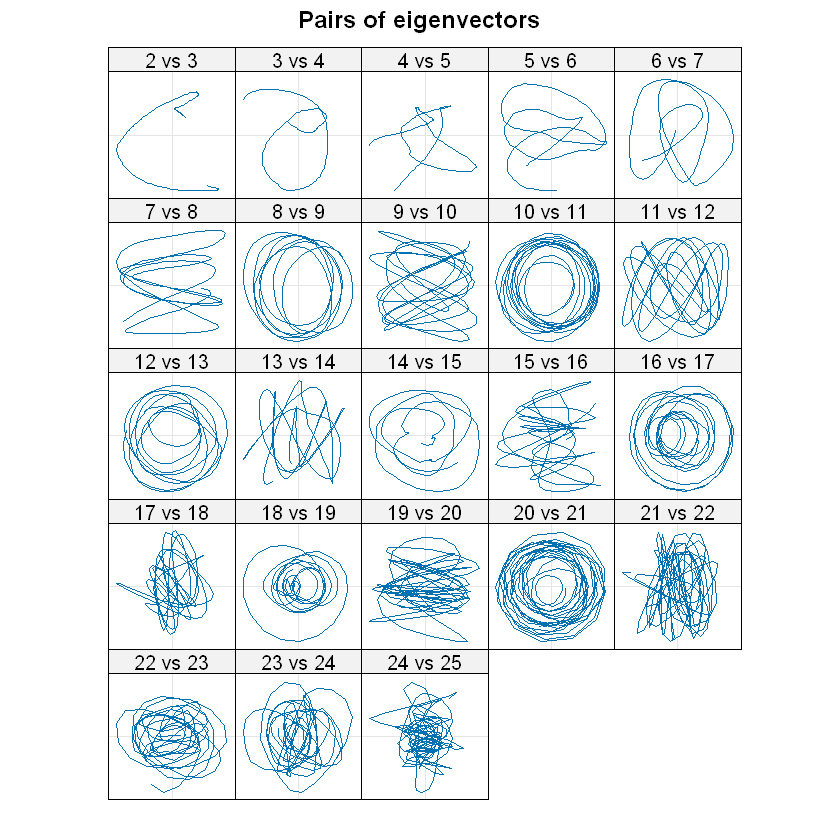

In [9]:
#Grafica 2D
plot(s1, type= "paired", idx=2:24, plot.contrib = FALSE)

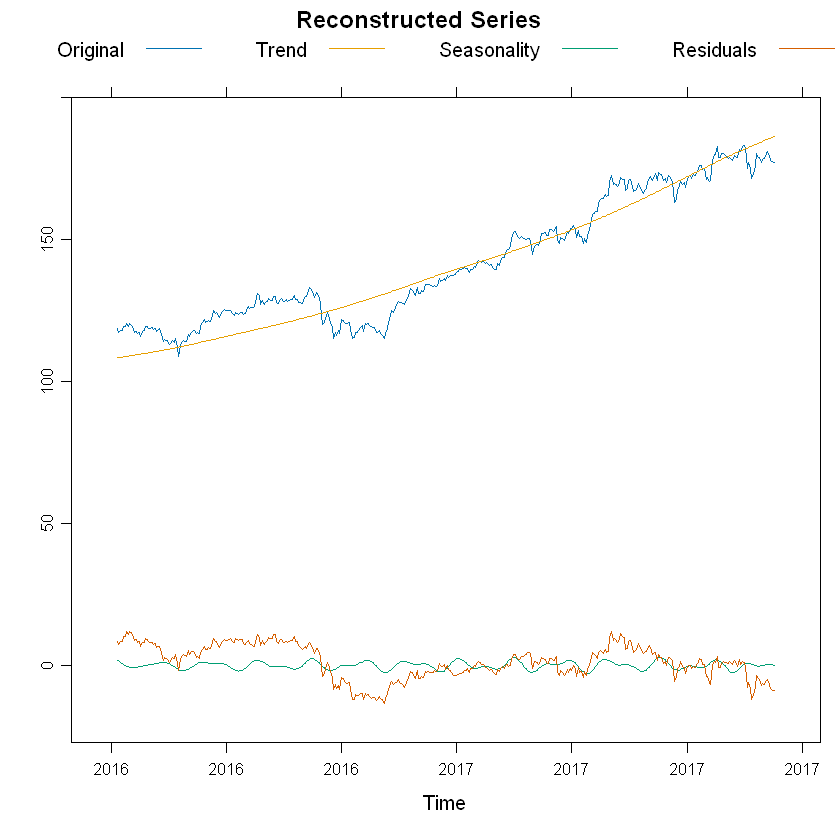

In [10]:
#Fase recontrucción:
r=reconstruct(s1, groups = list(Trend=1, Seasonality=c(8:9, 10:11)))
plot(r, add.residuals=TRUE, add.original=TRUE, plot.method="xyplot",
     superpose=TRUE, auto.key=list(columns=4))

In [11]:
#Generar el pronóstico .
pronostico1<-forecast(s1, groups = list(c(1, 8:11)), len=h, method="recurrent",
                                        interval = "prediction", level=c(0.8, 0.99),only.new=TRUE )

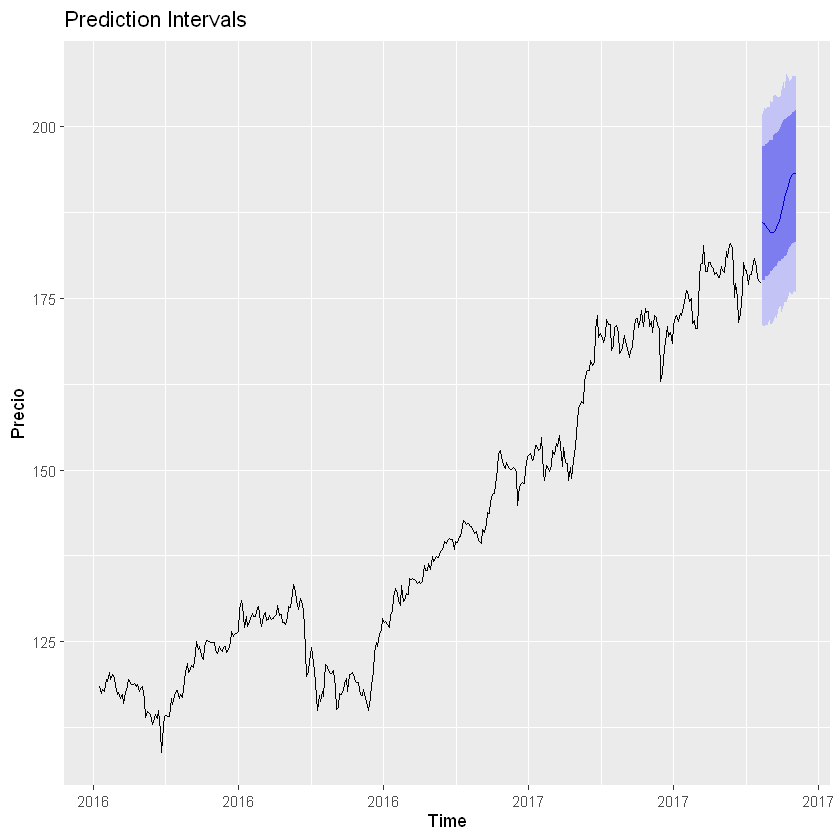

In [12]:
# Graficar el pronóstico.
autoplot(pronostico1, type="l", main="Prediction Intervals", ylab="Precio")

In [13]:
pred<-pronostico1$mean

In [14]:
#Metricas
RMSE1<-rmse(test,pred)
MAPE1<-mape(test, pred)
MAE1 <- mae(test, pred)
cat("RMSE:", RMSE1, "\n")
cat("MAPE:", MAPE1 *100, "%\n")
cat("MAE:", MAE1, "\n")


RMSE: 6.82 
MAPE: 3.18 %
MAE: 5.76 
